# Single-report three-level summary

Deep-dive on **one** suite report: set `REPORT` below to a `report-*.json`
(or leave empty to auto-pick the newest one), then **Run All**. Everything
reads from the saved report: no model calls, safe to re-run.

Sections: per-task three-level matrix, one-figure level summary, Level 1
outcome grid + failure evidence, judge-vs-oracle, Level 2 path quality,
Level 3 components, and an episode-by-episode drill-down.

Self-contained: needs only pandas + matplotlib (any kernel works).

In [14]:
REPORT = "report-opus.json"  # e.g. "report-opus.json". Leave empty to use the newest report-*.json in the project root

In [15]:
import json
import statistics as st
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 140)

path = Path(REPORT)
assert path and path.exists(), "no report found — run `make suite MODEL=...` or set REPORT"
rep = json.loads(path.read_text(encoding="utf-8"))
TASKS, K = rep["tasks"], rep["k"]
TASK_IDS = [t["task_id"] for t in TASKS]
EPS = [(t, ep) for t in TASKS for ep in t["episodes"]]
OK = [(t, ep) for t, ep in EPS if ep["status"] != "error"]
JUDGED = [(t, ep) for t, ep in OK if ep.get("judge")]
print(f"{path.name}: model={rep['model_id']}  k={K}  tasks={len(TASKS)}  "
      f"episodes={len(EPS)} ({len(EPS) - len(OK)} errors)  config={rep['config_hash'][:12]}")

report-opus.json: model=claude-opus-5  k=3  tasks=9  episodes=27 (0 errors)  config=ada6a437aeb7


## Per-task three-level matrix

One row per task, all three levels side by side: Level-1 successes (and the
judge's parallel count), Level-2 path metrics averaged over episodes, and the
Level-3 frozen-fixture component scores. Green = healthy, red = broken.

In [16]:
rows = []
for t in TASKS:
    ok = [ep for ep in t["episodes"] if ep["status"] != "error"]
    l3 = t.get("level3") or {}
    mean2 = lambda key: st.mean(ep["level2"][key] for ep in ok) if ok else None
    rows.append({
        "task": t["task_id"], "capability": t["capability"],
        "L1": f"{t['level1_successes']}/{t['k']}",
        "judge": (f"{t['judge_successes']}/{t['k']}"
                  if t.get("judge_successes") is not None else "-"),
        "node_f1": mean2("node_f1"), "edge_f1": mean2("edge_f1"),
        "order": mean2("order_conformance"), "redund": mean2("redundancy_ratio"),
        "policies": st.mean(ep["policies_passed"] for ep in ok) if ok else None,
        "intent": ("ok" if l3.get("intent_correct") else "WRONG") if l3 else "-",
        "slots": l3.get("slot_accuracy"),
        "recall@k": l3.get("selection_recall_at_k"),
        "binding": l3.get("binding_accuracy"),
    })
MATRIX = pd.DataFrame(rows).set_index("task")
graded = ["node_f1", "edge_f1", "order", "policies", "slots", "recall@k", "binding"]
MATRIX.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, subset=graded) \
      .format(precision=2, na_rep="-")

,capability,L1,judge,node_f1,edge_f1,order,redund,policies,intent,slots,recall@k,binding
task,,,,,,,,,,,,
cancel-bruno-refusal-unpaid,cancel_order,3/3,3/3,1.00,1.00,1.00,0.00,1,ok,1.00,1.00,1.00
cancel-dev-pending-installation,cancel_order,3/3,3/3,0.94,0.91,1.00,0.00,1,ok,1.00,1.00,1.00
cancel-vlad-order,cancel_order,3/3,3/3,1.00,1.00,1.00,0.00,1,ok,1.00,1.00,1.00
downgrade-alice-legacy-refusal,service_update,3/3,3/3,1.00,1.00,1.00,0.00,1,ok,1.00,1.00,1.00
info-dev-active-order-id,subscriber_info,3/3,3/3,1.00,1.00,1.00,0.00,1,ok,1.00,1.00,1.00
reschedule-erin-nothing-pending,reschedule_appointment,3/3,1/3,1.00,1.00,1.00,0.00,1,ok,0.50,1.00,1.00
reschedule-vlad-aug5-afternoon,reschedule_appointment,1/3,3/3,0.92,0.83,1.00,0.00,1,ok,0.67,1.00,1.00
upgrade-erin-fiber500,service_update,3/3,3/3,0.83,0.67,1.00,0.00,1,ok,1.00,1.00,1.00
view-carol-next-visit,view_appointments,3/3,3/3,1.00,1.00,1.00,0.00,1,ok,1.00,1.00,1.00


## Three-level summary (one figure)

Whole-run averages per level: outcome (L1 + judge), path quality (L2), and
component health (L3). This is the "how healthy is this agent" glance.

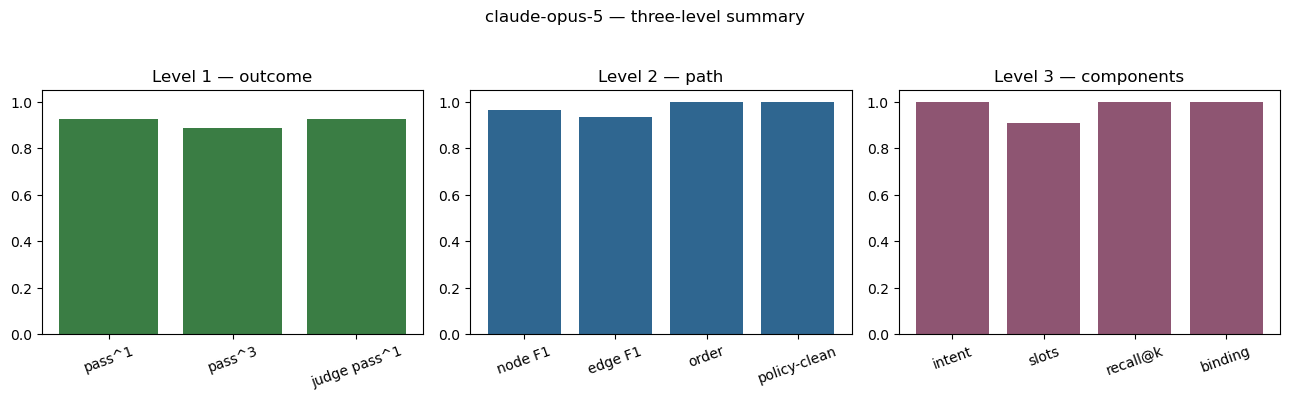

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

l1 = {"pass^1": st.mean(t["pass_hat_k"]["1"] for t in TASKS),
      f"pass^{K}": st.mean(t["pass_hat_k"][str(K)] for t in TASKS)}
if JUDGED:
    l1["judge pass^1"] = st.mean(t["judge_pass_hat_k"]["1"] for t in TASKS
                                 if t.get("judge_pass_hat_k"))
axes[0].bar(l1.keys(), l1.values(), color="#3a7d44")
axes[0].set_title("Level 1 — outcome")

l2 = {"node F1": st.mean(ep["level2"]["node_f1"] for _, ep in OK),
      "edge F1": st.mean(ep["level2"]["edge_f1"] for _, ep in OK),
      "order": st.mean(ep["level2"]["order_conformance"] for _, ep in OK),
      "policy-clean": st.mean(ep["policies_passed"] for _, ep in OK)}
axes[1].bar(l2.keys(), l2.values(), color="#2f6690")
axes[1].set_title("Level 2 — path")

l3s = [t["level3"] for t in TASKS if t.get("level3")]
if l3s:
    l3 = {"intent": st.mean(x["intent_correct"] for x in l3s),
          "slots": st.mean(x["slot_accuracy"] for x in l3s),
          "recall@k": st.mean(x["selection_recall_at_k"] for x in l3s),
          "binding": st.mean(x["binding_accuracy"] for x in l3s)}
    axes[2].bar(l3.keys(), l3.values(), color="#8e5572")
axes[2].set_title("Level 3 — components")

for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"{rep['model_id']} — three-level summary", y=1.04)
plt.tight_layout()
plt.show()

## Level 1

Every episode as a cell (green pass, red fail): the oracle's verdicts next to
the judge's, so per-episode disagreement is visible at a glance. Below the
grid, each Level-1 failure with its state-diff evidence.

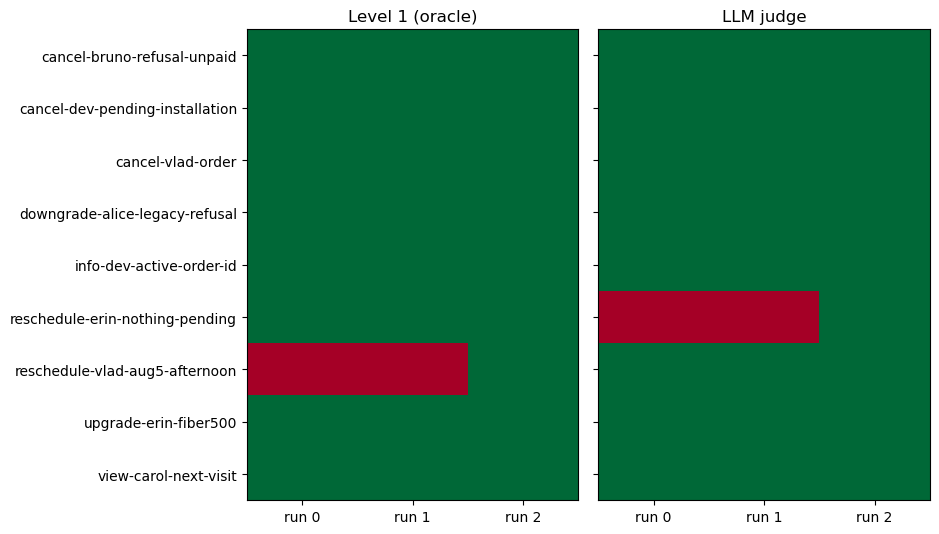

In [18]:
def verdict_grid(kind):
    g = np.full((len(TASKS), K), np.nan)
    for i, t in enumerate(TASKS):
        for ep in t["episodes"]:
            if ep["status"] == "error":
                continue
            if kind == "L1":
                g[i, ep["run"]] = ep["level1_passed"]
            elif ep.get("judge"):
                g[i, ep["run"]] = ep["judge"]["passed"]
    return g

grids = [("Level 1 (oracle)", verdict_grid("L1"))]
if JUDGED:
    grids.append(("LLM judge", verdict_grid("judge")))
fig, axes = plt.subplots(1, len(grids),
                         figsize=(3.0 * len(grids) + 3.5, 0.45 * len(TASKS) + 1.4),
                         squeeze=False)
for ax, (title, g) in zip(axes[0], grids):
    ax.imshow(g, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(K), [f"run {r}" for r in range(K)])
    ax.set_yticks(range(len(TASKS)), TASK_IDS)
    ax.set_title(title)
for ax in axes[0][1:]:
    ax.set_yticklabels([])
plt.tight_layout()
plt.show()

In [19]:
n = 0
for t in TASKS:
    for ep in t["episodes"]:
        if ep["status"] == "error":
            print(f"-- {t['task_id']} run {ep['run']}: ERROR {ep['error']}\n")
            n += 1
            continue
        if ep["level1_passed"]:
            continue
        n += 1
        print(f"-- {t['task_id']} run {ep['run']} — L1 FAIL")
        print(f"   instruction: {ep['instruction']}")
        for d in ep["level1"]["diffs"]:
            print(f"   diff: {d}")
        if ep.get("judge"):
            j = ep["judge"]
            print(f"   judge: {'PASS' if j['passed'] else 'FAIL'} — {j['reasoning']}")
        print(f"   reply: {ep.get('summary')}\n")
if n == 0:
    print("no Level-1 failures — every episode reached the goal state")

-- reschedule-vlad-aug5-afternoon run 0 — L1 FAIL
   instruction: Reschedule Vlad Grybennikov's maintenance visit to the afternoon of August 5.
   diff: appointments/APT-0407.notes: expected 'Wi-Fi coverage check.', got 'Rescheduled to afternoon of August 5, 2026 (14:00-16:00).'
   judge: PASS — The agent identified the correct subscriber and pending maintenance appointment, checked available slots for Aug 5 in the correct region, released the old slot, booked an afternoon slot (14:00-16:00), and updated the appointment accordingly. Slot state hygiene was handled correctly and the final reply accurately reflects the changes. The only quibble is overwriting the prior note text rather than appending, which is a minor, non-disqualifying issue.
   reply: Rescheduled Vlad Grybennikov's maintenance visit (APT-0407 on order ORD-0108) to the afternoon of August 5, 2026, 14:00-16:00. The old slot SLT-0322 (Aug 4, 11:00-13:00) was released and the new slot SLT-0326 booked; the appointment remain

## Judge vs oracle

Confusion matrix between the deterministic Level-1 verdict and the LLM judge,
plus every disagreeing episode with the judge's reasoning. The agreement rate
is the measured judge-reliability number.

In [20]:
if not JUDGED:
    print('no judge verdicts in this report — rerun with FLAGS="--judge"')
else:
    pairs = [(ep["level1_passed"], ep["judge"]["passed"]) for _, ep in JUDGED]
    conf = pd.DataFrame(
        [[sum(l and j for l, j in pairs), sum(l and not j for l, j in pairs)],
         [sum(j and not l for l, j in pairs), sum(not (l or j) for l, j in pairs)]],
        index=["L1 pass", "L1 fail"], columns=["judge pass", "judge fail"])
    agree = sum(l == j for l, j in pairs) / len(pairs)
    print(f"agreement: {agree:.3f} over {len(pairs)} episodes "
          f"(lenient={conf.loc['L1 fail', 'judge pass']}, "
          f"strict={conf.loc['L1 pass', 'judge fail']})")
    display(conf)
    dis = [{"task": t["task_id"], "run": ep["run"], "L1": ep["level1_passed"],
            "judge": ep["judge"]["passed"], "judge reasoning": ep["judge"]["reasoning"]}
           for t, ep in JUDGED if ep["judge"]["passed"] != ep["level1_passed"]]
    display(pd.DataFrame(dis) if dis else "judge and oracle agree on every episode")

agreement: 0.852 over 27 episodes (lenient=2, strict=2)


,judge pass,judge fail
L1 pass,23,2
L1 fail,2,0


,task,run,L1,judge,judge reasoning
0,reschedule-erin-nothing-pending,0,True,False,The agent only queried appointments filtered to status 'pending' and never checked other statuses (e.g. scheduled/confirmed) or listed a...
1,reschedule-erin-nothing-pending,1,True,False,"The agent only queried appointments with status 'pending' and, finding none, concluded there was nothing to reschedule without checking ..."
2,reschedule-vlad-aug5-afternoon,0,False,True,"The agent identified the correct subscriber and pending maintenance appointment, checked available slots for Aug 5 in the correct region..."
3,reschedule-vlad-aug5-afternoon,1,False,True,"Agent found the correct subscriber/appointment, released the old slot, booked an afternoon Aug 5 slot, updated the appointment, and tran..."


## Level 2

How the agent moved through the dependency graph, averaged over the task's
episodes. Redundant calls and policy violations are called out below.

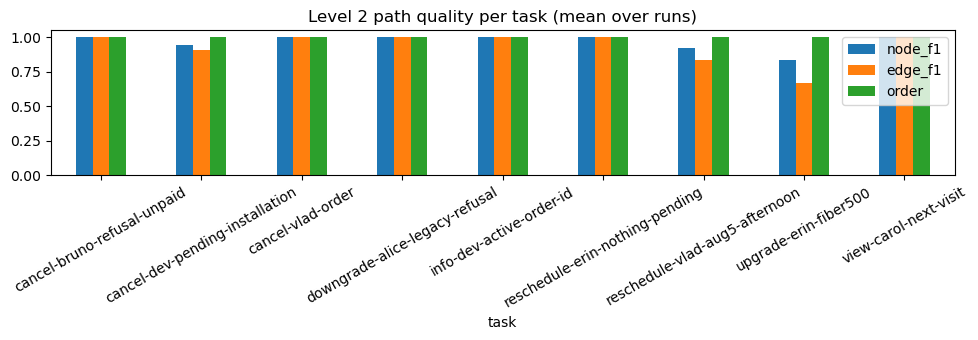

In [21]:
l2df = pd.DataFrame([
    {"task": t["task_id"], "node_f1": ep["level2"]["node_f1"],
     "edge_f1": ep["level2"]["edge_f1"], "order": ep["level2"]["order_conformance"]}
    for t, ep in OK]).groupby("task").mean().reindex(TASK_IDS)
ax = l2df.plot.bar(figsize=(10, 3.5), rot=30,
                   title="Level 2 path quality per task (mean over runs)")
ax.set_ylim(0, 1.05)
ax.legend(title=None)
plt.tight_layout()
plt.show()

for t, ep in OK:
    l2 = ep["level2"]
    if l2["redundancy_ratio"] > 0:
        print(f"redundant calls: {t['task_id']} run {ep['run']} "
              f"ratio={l2['redundancy_ratio']}")
    if not ep["policies_passed"]:
        failed = [p for p in l2.get("policy_results", []) if not p.get("passed")]
        print(f"POLICY VIOLATION: {t['task_id']} run {ep['run']} — "
              + "; ".join(str(p) for p in failed))

## Level 3
Per-task frozen-fixture scores (slot extraction, tool-selection Recall@k,
argument binding), then the labeled intent set when the report carries one.

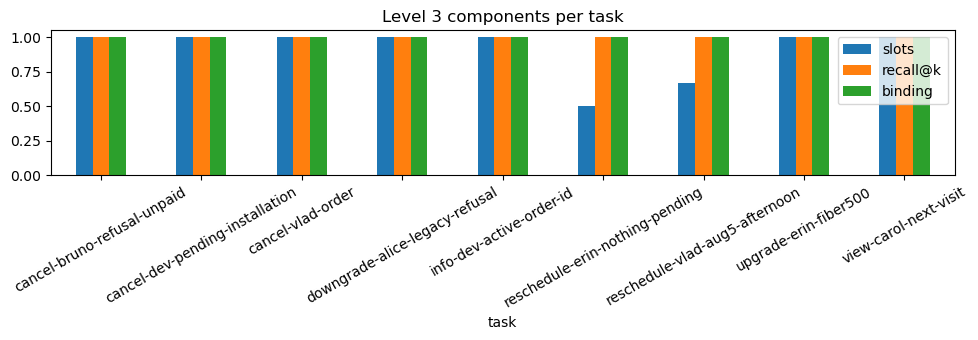


intent set: accuracy=1.0  macro_f1=1.0


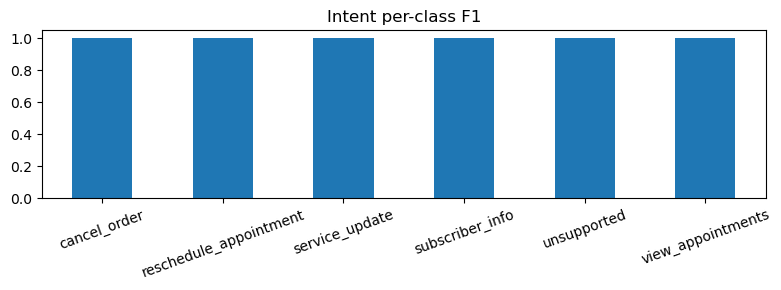

In [22]:
comp = MATRIX[["slots", "recall@k", "binding"]].dropna(how="all")
if comp.empty:
    print("no level-3 fixtures in this report")
else:
    ax = comp.plot.bar(figsize=(10, 3.5), rot=30,
                       title="Level 3 components per task")
    ax.set_ylim(0, 1.05)
    ax.legend(title=None)
    plt.tight_layout()
    plt.show()
    wrong = MATRIX[MATRIX["intent"] == "WRONG"]
    if not wrong.empty:
        print("intent misclassified on:", ", ".join(wrong.index))

ic = rep.get("intent_classification")
if ic:
    print(f"\nintent set: accuracy={ic['accuracy']}  macro_f1={ic['macro_f1']}")
    for miss in ic["errors"]:
        print(f"  MISS {miss['utterance']!r}  expected={miss['expected']}  got={miss['predicted']}")
    f1s = pd.Series({label: m["f1"] for label, m in ic["per_class"].items()})
    ax = f1s.plot.bar(figsize=(8, 3), rot=20, title="Intent per-class F1")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

## Episode drill-down

`show_episode(task_id, run)` replays one episode from the saved trace:
every call in order (rejected calls marked), the projected state delta, and
the verdicts. The cell below auto-shows the first Level-1 failure, if any.

In [23]:
DROP_TABLES = {"events"}
DROP_FIELDS = {"orders": {"cancelled_at"}}

def _project(snapshot):
    return {table: {str(row["id"]): {k: v for k, v in row.items()
                                     if k not in DROP_FIELDS.get(table, ())}
                    for row in rows}
            for table, rows in snapshot["tables"].items()
            if table not in DROP_TABLES}

def state_delta(trace):
    initial = _project(trace["initial_snapshot"])
    final = _project(trace["final_snapshot"])
    lines = []
    for table, rows in initial.items():
        for row_id, row in rows.items():
            after = final.get(table, {}).get(row_id)
            if after is None:
                lines.append(f"{table}/{row_id}: row removed")
                continue
            lines.extend(f"{table}/{row_id}.{col}: {before!r} -> {after.get(col)!r}"
                         for col, before in row.items() if after.get(col) != before)
    for table, rows in final.items():
        lines.extend(f"{table}/{row_id}: row added"
                     for row_id in rows if row_id not in initial.get(table, {}))
    return lines

def show_episode(task_id, run=0):
    t = next(t for t in TASKS if t["task_id"] == task_id)
    ep = t["episodes"][run]
    if ep["status"] == "error":
        print("episode errored:", ep["error"])
        return
    trace = ep["trace"]
    print(f"instruction: {trace['instruction']}")
    print(f"intent={trace['intent']}  slots={trace['slots']}")
    for s in trace["steps"]:
        if not s.get("call"):
            print(f"  {s['index']:2d}. (bind failure: {s.get('error')})")
            continue
        mark = f"  [REJECTED: {s['error']}]" if s.get("error") else ""
        print(f"  {s['index']:2d}. {s['call']['tool']}({json.dumps(s['call']['args'])}){mark}")
    print("state delta:")
    for line in state_delta(trace) or ["(no changes)"]:
        print("  " + line)
    print(f"status={ep['status']}  L1={'PASS' if ep['level1_passed'] else 'FAIL'}  "
          f"policies={'ok' if ep['policies_passed'] else 'VIOLATED'}")
    print("reply:", ep.get("summary"))

first_fail = next(((t["task_id"], ep["run"]) for t in TASKS for ep in t["episodes"]
                   if ep["status"] != "error" and not ep["level1_passed"]), None)
if first_fail:
    print(f">>> first Level-1 failure: {first_fail[0]} run {first_fail[1]}\n")
    show_episode(*first_fail)
else:
    print("no failures to show — call show_episode(task_id, run) manually")

>>> first Level-1 failure: reschedule-vlad-aug5-afternoon run 0

instruction: Reschedule Vlad Grybennikov's maintenance visit to the afternoon of August 5.
intent=reschedule_appointment  slots={'subscriber_name': 'Vlad Grybennikov', 'subscriber_email': None, 'order_id': None, 'appointment_id': None, 'target_plan': None, 'target_date': '2025-08-05', 'target_time_window': 'afternoon', 'requested_field': None, 'notes': 'Maintenance visit to be rescheduled to afternoon of August 5.'}
   0. find_subscriber({"name_or_email": "Vlad Grybennikov"})
   1. list_appointments({"subscriber_id": "SUB-0007", "status": "pending"})
   2. get_order({"order_id": "ORD-0108"})
   3. list_available_slots({"region": "west", "date": "2026-08-05"})
   4. release_slot({"slot_id": "SLT-0322"})
   5. book_slot({"slot_id": "SLT-0326"})
   6. update_appointment({"appointment_id": "APT-0407", "slot_id": "SLT-0326", "status": "pending", "notes": "Rescheduled to afternoon of August 5, 2026 (14:00-16:00)."})
   7. finis